In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from spekk import ops
# from vbeam.geometry import as_cartesian
from vbeam.geometry.coordinate_systems import polar_to_cartesian


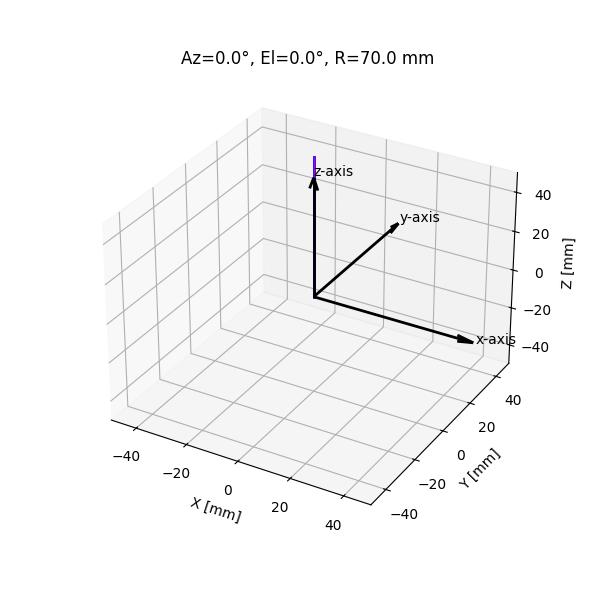

In [2]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)
ax.set_zlim(-50, 50)
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_zlabel("Z [mm]")

ax.plot([0, 0],
        [0, 0],
        [0, 60],
        color="k", linewidth=1)


ax.quiver(0, 0, 0,
          60, 0, 0,
          arrow_length_ratio=0.1, color="k", linewidth=2)
ax.text(60 + 1, 0, 0, "x-axis", color="k")

ax.quiver(0, 0, 0,
          0, 60, 0,
          arrow_length_ratio=0.1, color="k", linewidth=2)
ax.text(0, 60 + 1, 0, "y-axis", color="k")

ax.quiver(0, 0, 0,
          0, 0, 60,
          arrow_length_ratio=0.1, color="k", linewidth=2)
ax.text(0, 0, 60 + 1, "z-axis", color="k")


line = None
line_yz = None

def update(az_deg, el_deg, radius, view_yz=False):

    if view_yz:
        ax.view_init(elev=0, azim=0)

    # Build polar point
    az = ops.array([az_deg * ops.pi / 180], dims=["az"])
    el = ops.array([el_deg * ops.pi / 180], dims=["el"])
    r = ops.array([0, radius], dims=["depth"])

    point = ops.stack([az, el, r], axis="az_el_depth")

    global line
    global line_yz
    if line is not None:
        line.remove()
        line_yz.remove()
        
    p = polar_to_cartesian(point)  # radius
    line, = ax.plot(
            [p["xyz", 0, "depth", 0], p["xyz", 0, "depth", 1]],
            [p["xyz", 1, "depth", 0], p["xyz", 1, "depth", 1]],
            [p["xyz", 2, "depth", 0], p["xyz", 2, "depth", 1]],
            # color=colors[p_idx], linewidth=2)
            color="b", linewidth=2)
    
    line_yz, = ax.plot(
            [0, 0],
            [p["xyz", 1, "depth", 0], p["xyz", 1, "depth", 1]],
            [p["xyz", 2, "depth", 0], p["xyz", 2, "depth", 1]],
            # color=colors[p_idx], linewidth=2)
            color="m", linewidth=1)
    
    ax.set_title(f"Az={az_deg:.1f}°, El={el_deg:.1f}°, R={radius:.1f} mm")
    fig.canvas.draw_idle()

def refresh_from_sliders(_=None):
    update(az_slider.value, el_slider.value, r_slider.value, view_yz=False)

az_slider = widgets.FloatSlider(min=-80, max=80, step=1, value=0, description="Azimuth [°]")
el_slider = widgets.FloatSlider(min=-90, max=90, step=1, value=0, description="Elevation [°]")
r_slider  = widgets.FloatSlider(min=0, max=70, step=1, value=70, description="Radius [mm]", continuous_update=False)

button_yz = widgets.Button(description="View yz-plane")

def on_view_yz(_):
    update(az_slider.value, el_slider.value, r_slider.value, view_yz=True)

az_slider.observe(refresh_from_sliders, names="value")
el_slider.observe(refresh_from_sliders, names="value")
r_slider.observe(refresh_from_sliders, names="value")
button_yz.on_click(on_view_yz)

display(widgets.VBox([widgets.HBox([az_slider, el_slider, r_slider]), button_yz]))
refresh_from_sliders()


a = 1
